In [19]:
import os
# Java 8 path
os.environ['JAVA_HOME'] = '/Library/Java/JavaVirtualMachines/temurin-8.jdk/Contents/Home'

# PySpark path
os.environ['SPARK_HOME'] = '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pyspark'

In [20]:
from pyspark.sql.functions import *
from pyspark.sql.types import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Categorical Analaysis") \
    .getOrCreate()

In [22]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_pd = pd.read_csv(url)
titanic_df = spark.createDataFrame (titanic_pd)
titanic_df.show (5)

[Stage 0:>                                                          (0 + 1) / 1]

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25|  NaN|       S|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925|  NaN|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|   53.1| C123|       S|
|          5|       0|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|          373450|   8.05|  NaN|       S|
+-----------+--------+------+--------------------+------+----+-----+-----+------

In [23]:
titanic_df.printSchema () #shows the datatype and no.of columns

root
 |-- PassengerId: long (nullable = true)
 |-- Survived: long (nullable = true)
 |-- Pclass: long (nullable = true)
 |-- Name: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- SibSp: long (nullable = true)
 |-- Parch: long (nullable = true)
 |-- Ticket: string (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Cabin: string (nullable = true)
 |-- Embarked: string (nullable = true)



In [24]:
titanic_df.count()

891

In [25]:
len(titanic_df.columns)


12

In [26]:
#Long values change to categorical data analsysis 
titanic_clean = titanic_df.select(
    'Survived' , 'Pclass' , 'Name' , col('Sex').alias('Gender'),'Age','Fare')
titanic_clean.show(5)

+--------+------+--------------------+------+----+-------+
|Survived|Pclass|                Name|Gender| Age|   Fare|
+--------+------+--------------------+------+----+-------+
|       0|     3|Braund, Mr. Owen ...|  male|22.0|   7.25|
|       1|     1|Cumings, Mrs. Joh...|female|38.0|71.2833|
|       1|     3|Heikkinen, Miss. ...|female|26.0|  7.925|
|       1|     1|Futrelle, Mrs. Ja...|female|35.0|   53.1|
|       0|     3|Allen, Mr. Willia...|  male|35.0|   8.05|
+--------+------+--------------------+------+----+-------+
only showing top 5 rows



In [32]:
titanic_clean.printSchema ()

root
 |-- Survived: long (nullable = true)
 |-- Pclass: long (nullable = true)
 |-- Name: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- Fare: double (nullable = true)



In [34]:
titanic_clean.describe().show()


25/12/08 09:55:18 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 5:>                                                          (0 + 8) / 8]

+-------+-------------------+-----------------+--------------------+------+----+-----------------+
|summary|           Survived|           Pclass|                Name|Gender| Age|             Fare|
+-------+-------------------+-----------------+--------------------+------+----+-----------------+
|  count|                891|              891|                 891|   891| 891|              891|
|   mean| 0.3838383838383838|2.308641975308642|                null|  null| NaN|32.20420796857464|
| stddev|0.48659245426485753|0.836071240977049|                null|  null| NaN|49.69342859718089|
|    min|                  0|                1| Abbing, Mr. Anthony|female|0.42|              0.0|
|    max|                  1|                3|van Melkebeke, Mr...|  male| NaN|         512.3292|
+-------+-------------------+-----------------+--------------------+------+----+-----------------+



In [51]:
titanic_clean1 = titanic_clean.withColumn('Survived', when(col('Survived') == 0 , 'No').otherwise('Yes'))
titanic_clean1.show()

+--------+------+--------------------+------+----+-------+
|Survived|Pclass|                Name|Gender| Age|   Fare|
+--------+------+--------------------+------+----+-------+
|      No|     3|Braund, Mr. Owen ...|  male|22.0|   7.25|
|     Yes|     1|Cumings, Mrs. Joh...|female|38.0|71.2833|
|     Yes|     3|Heikkinen, Miss. ...|female|26.0|  7.925|
|     Yes|     1|Futrelle, Mrs. Ja...|female|35.0|   53.1|
|      No|     3|Allen, Mr. Willia...|  male|35.0|   8.05|
|      No|     3|    Moran, Mr. James|  male| NaN| 8.4583|
|      No|     1|McCarthy, Mr. Tim...|  male|54.0|51.8625|
|      No|     3|Palsson, Master. ...|  male| 2.0| 21.075|
|     Yes|     3|Johnson, Mrs. Osc...|female|27.0|11.1333|
|     Yes|     2|Nasser, Mrs. Nich...|female|14.0|30.0708|
|     Yes|     3|Sandstrom, Miss. ...|female| 4.0|   16.7|
|     Yes|     1|Bonnell, Miss. El...|female|58.0|  26.55|
|      No|     3|Saundercock, Mr. ...|  male|20.0|   8.05|
|      No|     3|Andersson, Mr. An...|  male|39.0| 31.27

In [52]:
titanic_clean1 = titanic_clean1.withColumn('Pclass' , when(col('Pclass') == 1 ,'FirstClass')
                                          .when(col('Pclass') ==2,'Second').otherwise('Third'))
titanic_clean1.show()

+--------+----------+--------------------+------+----+-------+
|Survived|    Pclass|                Name|Gender| Age|   Fare|
+--------+----------+--------------------+------+----+-------+
|      No|     Third|Braund, Mr. Owen ...|  male|22.0|   7.25|
|     Yes|FirstClass|Cumings, Mrs. Joh...|female|38.0|71.2833|
|     Yes|     Third|Heikkinen, Miss. ...|female|26.0|  7.925|
|     Yes|FirstClass|Futrelle, Mrs. Ja...|female|35.0|   53.1|
|      No|     Third|Allen, Mr. Willia...|  male|35.0|   8.05|
|      No|     Third|    Moran, Mr. James|  male| NaN| 8.4583|
|      No|FirstClass|McCarthy, Mr. Tim...|  male|54.0|51.8625|
|      No|     Third|Palsson, Master. ...|  male| 2.0| 21.075|
|     Yes|     Third|Johnson, Mrs. Osc...|female|27.0|11.1333|
|     Yes|    Second|Nasser, Mrs. Nich...|female|14.0|30.0708|
|     Yes|     Third|Sandstrom, Miss. ...|female| 4.0|   16.7|
|     Yes|FirstClass|Bonnell, Miss. El...|female|58.0|  26.55|
|      No|     Third|Saundercock, Mr. ...|  male|20.0| 

In [53]:
titanic_clean1.printSchema()

root
 |-- Survived: string (nullable = false)
 |-- Pclass: string (nullable = false)
 |-- Name: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- Fare: double (nullable = true)



In [56]:
# You can use pandas for thisone , however you should conver the spark data frame to pandas dataframe
titanic_clean_pd = titanic_clean.toPandas()
titanic_clean_pd.head()

,Survived,Pclass,Name,Gender,Age,Fare
0,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833
2,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000
4,0,3,"Allen, Mr. William Henry",male,35.0,8.0500


In [58]:
titanic_clean_pd['Survived'] = titanic_clean_pd['Survived'].map({0:'No' , 1: 'Yes'})
titanic_clean_pd['Pclass'] = titanic_clean_pd['Pclass'].map({1:'FirstClass' , 2: 'SecondClass', 3: 'ThirdClass'})
titanic_clean_pd.head()

,Survived,Pclass,Name,Gender,Age,Fare
0,No,ThirdClass,"Braund, Mr. Owen Harris",male,22.0,7.2500
1,Yes,FirstClass,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833
2,Yes,ThirdClass,"Heikkinen, Miss. Laina",female,26.0,7.9250
3,Yes,FirstClass,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000
4,No,ThirdClass,"Allen, Mr. William Henry",male,35.0,8.0500


In [59]:
titanic_clean_pd.dtypes

Survived     object
Pclass       object
Name         object
Gender       object
Age         float64
Fare        float64
dtype: object

In [60]:
titanic_clean_pd.describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


In [61]:
#Count summaries for categorical variables 
titanic_clean1.groupBy('Survived').count().orderBy('Survived').show()

[Stage 19:>                                                         (0 + 8) / 8]

+--------+-----+
|Survived|count|
+--------+-----+
|      No|  549|
|     Yes|  342|
+--------+-----+



In [62]:
#Count summaries for categorical variables 
titanic_clean1.groupBy('Pclass').count().orderBy('Pclass').show()

+----------+-----+
|    Pclass|count|
+----------+-----+
|FirstClass|  216|
|    Second|  184|
|     Third|  491|
+----------+-----+



In [63]:
#Count summaries for categorical variables 
titanic_clean1.groupBy('Gender').count().orderBy('Gender').show()

+------+-----+
|Gender|count|
+------+-----+
|female|  314|
|  male|  577|
+------+-----+



In [90]:
missing_count = titanic_clean1.select([
    count(when(isnull(c) | isnan(c), c)).alias(f"{c}_missing")
    for c in ['Age', 'Fare', 'Survived', 'Pclass', 'Gender']
])

missing_count.show()

+-----------+------------+----------------+--------------+--------------+
|Age_missing|Fare_missing|Survived_missing|Pclass_missing|Gender_missing|
+-----------+------------+----------------+--------------+--------------+
|        177|           0|               0|             0|             0|
+-----------+------------+----------------+--------------+--------------+



In [71]:
titanic_clean_pd[['Age' , 'Fare' , 'Survived' , 'Pclass' , 'Gender']].isnull().sum()

Age         177
Fare          0
Survived      0
Pclass        0
Gender        0
dtype: int64

In [72]:
survived_gender = titanic_clean1.groupBy('Gender' , 'Survived').count()
survived_gender.orderBy('Gender' , 'Survived').show()

+------+--------+-----+
|Gender|Survived|count|
+------+--------+-----+
|female|      No|   81|
|female|     Yes|  233|
|  male|      No|  468|
|  male|     Yes|  109|
+------+--------+-----+



In [74]:
survived_pclass = titanic_clean1.groupBy('Survived' , 'Pclass').count()
survived_pclass.orderBy('Survived' , 'Pclass').show()

+--------+----------+-----+
|Survived|    Pclass|count|
+--------+----------+-----+
|      No|FirstClass|   80|
|      No|    Second|   97|
|      No|     Third|  372|
|     Yes|FirstClass|  136|
|     Yes|    Second|   87|
|     Yes|     Third|  119|
+--------+----------+-----+



<Axes: xlabel='Gender'>

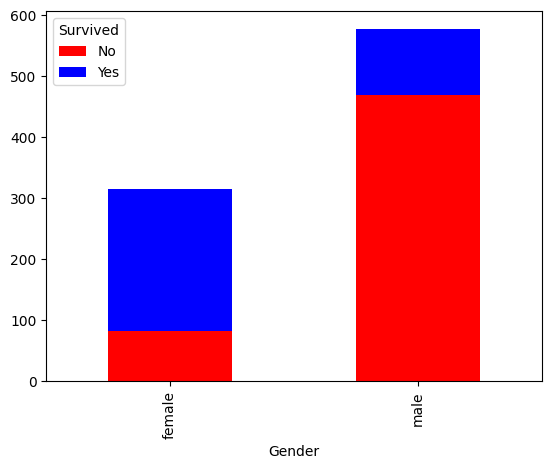

In [77]:
#plot1 : Surivde by gender 
survival_gender_pd = titanic_clean_pd.groupby(['Gender', 'Survived']).size().unstack(fill_value = 0)
survival_gender_pd.plot(kind = 'bar', stacked = True , color =['red','blue'])


<Axes: xlabel='Pclass'>

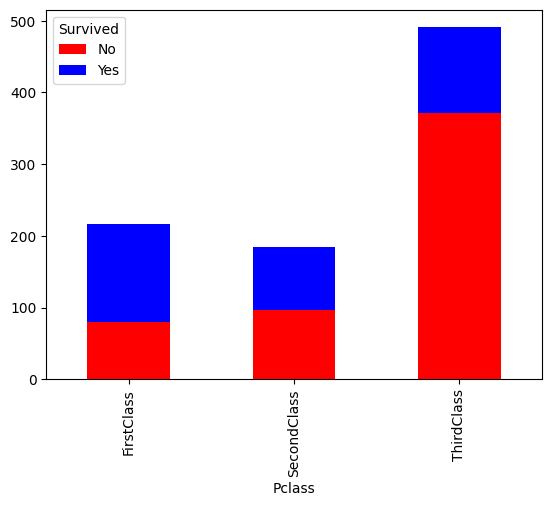

In [78]:
#plot1 : Surivde by gender 
survival_passenger_pd = titanic_clean_pd.groupby(['Pclass', 'Survived']).size().unstack(fill_value = 0)
survival_passenger_pd.plot(kind = 'bar', stacked = True , color =['red','blue'])


<Axes: xlabel='Pclass'>

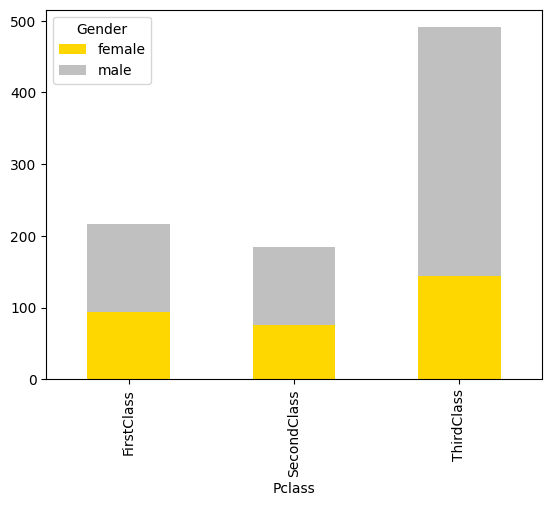

In [80]:
gender_passenger_pd = titanic_clean_pd.groupby(['Pclass', 'Gender']).size().unstack(fill_value = 0)
gender_passenger_pd.plot(kind = 'bar', stacked = True , color =['gold','silver'])


In [86]:
age_fare_pd = titanic_clean_pd[['Age','Fare']].dropna()
age_fare_pd

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
885,39.0,29.1250
886,27.0,13.0000
887,19.0,30.0000
889,26.0,30.0000


In [88]:
correlation = np.corrcoef(age_fare_pd['Age'],age_fare_pd['Fare'])
correlation[0,1]

0.09606669176903894